# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

**Adding a penalty to the mean squared error discourages large coefficients in the model. When coefficients become large, the model can fit the training data extremely well but may capture noise rather than acutal real patterns. The penalty forces the model to keep the coefficients smaller which can improve the generalization and discourage any overfitting.**

2. How does regularization provide a way of exploring the bias-variance trade-off?

**Regularization introduces bias into the model by shrinking cofficients toward zero. However, this reduction in flexibility decreases the variance because the model becomes less sensitive to fluctuations in the training data. When you adjust the penalty parameter, there is a balance in variance and bias in order to see better performance.**

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

**Ridge regression uses an L2 penalty, while LASSO uses a L1 penalty.Ridge shrinks coefficients toward zero and doesn't usually set them to zero, while LASSO shrinks them to zero.**

4. How do we typically scale variables for use in regularized regression? Why?

**Variables are standardized using a z score. Regularization penalizes coefficient size and if there are any variables that are on different scales then the variables with large scales would dominate the penalty and cause the results to have issues.**

5. How is the penalty $\alpha$ typically selected?

**The penalty parameter alpha is selected using cross validation, basically being the one that produces the lowest cross validated error is the best one.**

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**No, when you evaulate cross validation perfromance, you need to find the prediction MSE on the validation data. The penalty term is used during training to estimate coefficients, but not when measuring predicition accuracy.**

In [19]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

**The interaction term Mileage_Run x Age is negative. This suggests that cars that are both older and have higher mileage experience a stronger decrease in price compared to cars that are only old or only high mileage.**

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?

**LASSO selected 6 out of the 9 polynomial features (Mileage_Run, Age, Mileage_Run x Age, Mileage_Run^3, Mileage_Run x Age^2, Age^3) and set 3 equal to zero. (Milage_Run^2, Age^2, Mileage_Run^2 x Age) So about 33% of cofficients were eliminated, which shows LASSO performed feature selection.**

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

**Most coefficients shirnk toward zero under LASSO. The Age coefficient increased in magnitude probably because LASSO removed correlated predictors. Some cofficients changed sign or became zero because of regulatization pressure.**

In [20]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
import matplotlib.pyplot as plt

In [21]:
cars = pd.read_csv("cars_hw.csv")

cars["Age"] = cars["Make_Year"].max() - cars["Make_Year"]

X = cars[["Mileage_Run","Age"]]

y = cars["Price"]

In [22]:
poly = PolynomialFeatures(degree=3, include_bias=False)

X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(X.columns)

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_poly)

In [24]:
linreg = LinearRegression()

linreg.fit(X_scaled,y)

lin_coefs = pd.Series(linreg.coef_,index=feature_names)

lin_coefs

,0
Mileage_Run,458071.119627
Age,-136698.072100
Mileage_Run^2,-91643.120024
Mileage_Run Age,-898405.751356
Age^2,113603.822348
Mileage_Run^3,-65144.896599
Mileage_Run^2 Age,229021.676556
Mileage_Run Age^2,368955.713359
Age^3,-84038.066146


In [25]:
alphas = np.logspace(1,3,20)

lasso = LassoCV(alphas=alphas,cv=20,max_iter=100000)

lasso.fit(X_scaled,y)

print("Best alpha:",lasso.alpha_)

Best alpha: 784.7599703514607


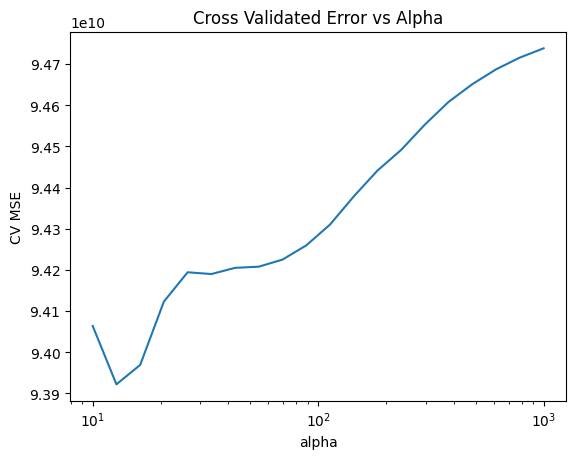

In [26]:
mse = np.mean(lasso.mse_path_,axis=1)

plt.plot(alphas,mse)

plt.xscale("log")

plt.xlabel("alpha")

plt.ylabel("CV MSE")

plt.title("Cross Validated Error vs Alpha")

plt.show()

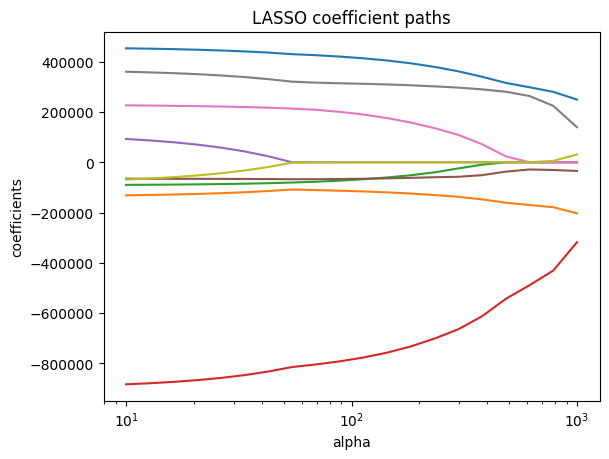

In [27]:
coefs=[]

for a in alphas:

    model=Lasso(alpha=a,max_iter=100000)

    model.fit(X_scaled,y)

    coefs.append(model.coef_)

coefs=np.array(coefs)

for i in range(coefs.shape[1]):

    plt.plot(alphas,coefs[:,i])

plt.xscale("log")

plt.xlabel("alpha")

plt.ylabel("coefficients")

plt.title("LASSO coefficient paths")

plt.show()

In [28]:
lasso_coefs=pd.Series(lasso.coef_,index=feature_names)

lasso_coefs

,0
Mileage_Run,279901.144475
Age,-178627.649418
Mileage_Run^2,-0.000000
Mileage_Run Age,-430522.371167
Age^2,-0.000000
Mileage_Run^3,-30772.352392
Mileage_Run^2 Age,0.000000
Mileage_Run Age^2,224381.027339
Age^3,5666.626835


In [29]:
comparison=pd.DataFrame({

"Linear Regression":linreg.coef_,

"LASSO":lasso.coef_

},index=feature_names)

comparison

,Linear Regression,LASSO
Mileage_Run,458071.119627,279901.144475
Age,-136698.072100,-178627.649418
Mileage_Run^2,-91643.120024,-0.000000
Mileage_Run Age,-898405.751356,-430522.371167
Age^2,113603.822348,-0.000000
Mileage_Run^3,-65144.896599,-30772.352392
Mileage_Run^2 Age,229021.676556,0.000000
Mileage_Run Age^2,368955.713359,224381.027339
Age^3,-84038.066146,5666.626835


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.


2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

**Some coefficients seem counterintuitive like higher age or higher serum creatinine might have a negative coefficient despite being clinical risk factors for death. I think this happens because OLS with a lot of correlated features like age, age sqaured, age to the third, and interactions between them. These features spread the effect across many correlated terms which ends up causing multicollinearity. The individual coefficients are undstable and hard to interpret in perfect isolation. For example, a negative coefficient on age could be cancelled out by a large positive coefficient on age squared. The higher order terms and interactions could solve contradictions by finding nonlinear relationships as well like risk could spped up nonlinearly at ages that are older and this could cause a negative linear term and a positive quadratic term together to express.**


3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**LASSO zeros out a large proportion of features, so only containing the most meaningful ones like serum_creatinine, ejection_fraction, and age. In terms of magnitude, LASSO doesn't increase coefficient magnitudes, but actually shrinks them
toward zero. For sign changes,some coefficients flip sign between OLS and LASSO. I believe this is because of  multicollinearity in OLS, where correlated features like age, age squared, and
age to the third destabilize each other's estimates. LASSO resolves this by zeroing terms that are redundant
and letting the rest have valuable and interpretable signs.**

**I think LASSO makes more sense. Lower ejection fraction and higher serum creatinine make sense for heart failure risk factors and LASSO recovers these directions. I think from a bias-variance type of perspective, OLS is pretty high variance with lots of correlated features which produces some unstable coefficients. I think that LASSO trades some bias for lower variance which makes it pretty stable in my opinion.**

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

continuous_vars = df[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree=3, include_bias=False)
continuous_poly = poly.fit_transform(continuous_vars)
continuous_names = poly.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

scaler = StandardScaler()
continuous_scaled = scaler.fit_transform(continuous_poly)

cat_vars = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly_cat = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
cat_interactions = poly_cat.fit_transform(cat_vars)
cat_names = poly_cat.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

X = np.hstack([continuous_scaled, cat_interactions])
feature_names = np.concatenate([continuous_names, cat_names])

y = df['DEATH_EVENT'].values

print("Feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])

Feature matrix shape: (299, 33)
Number of features: 33


In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': lr.coef_
})

print(coef_df.to_string(index=False))

                               Feature  OLS Coefficient
                                   age         1.549928
                     ejection_fraction        -2.025371
                      serum_creatinine        -0.739027
                                 age^2        -3.547991
                 age ejection_fraction        -0.861860
                  age serum_creatinine         1.680570
                   ejection_fraction^2         3.317931
    ejection_fraction serum_creatinine         2.604767
                    serum_creatinine^2        -2.703084
                                 age^3         1.889040
               age^2 ejection_fraction         1.022027
                age^2 serum_creatinine        -0.672141
               age ejection_fraction^2         0.017577
age ejection_fraction serum_creatinine        -1.584620
                age serum_creatinine^2         1.433246
                   ejection_fraction^3        -1.253594
  ejection_fraction^2 serum_creatinine        -1

In [32]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X, y)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")

Optimal alpha: 0.005736


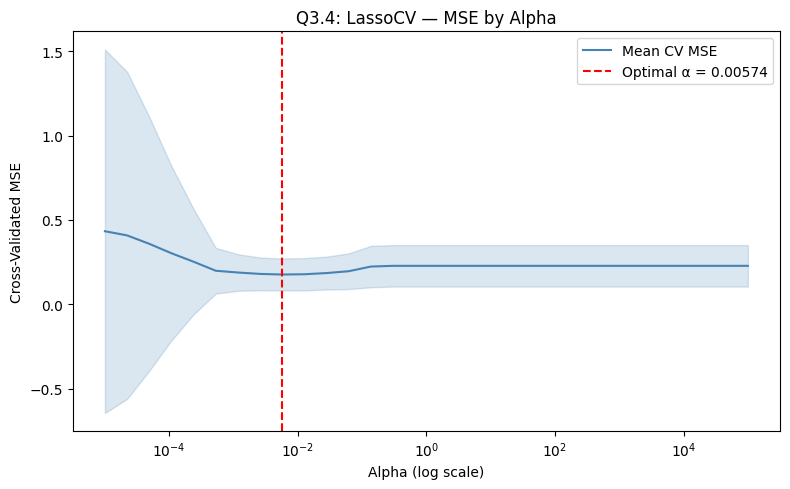

In [33]:
import matplotlib.pyplot as plt

mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
mse_std  = np.std(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cv.alphas_, mse_mean, color='steelblue', label='Mean CV MSE')
plt.fill_between(lasso_cv.alphas_,
                 mse_mean - mse_std,
                 mse_mean + mse_std,
                 alpha=0.2, color='steelblue')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Optimal α = {lasso_cv.alpha_:.5f}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('Q3.4: LassoCV — MSE by Alpha')
plt.legend()
plt.tight_layout()
plt.show()

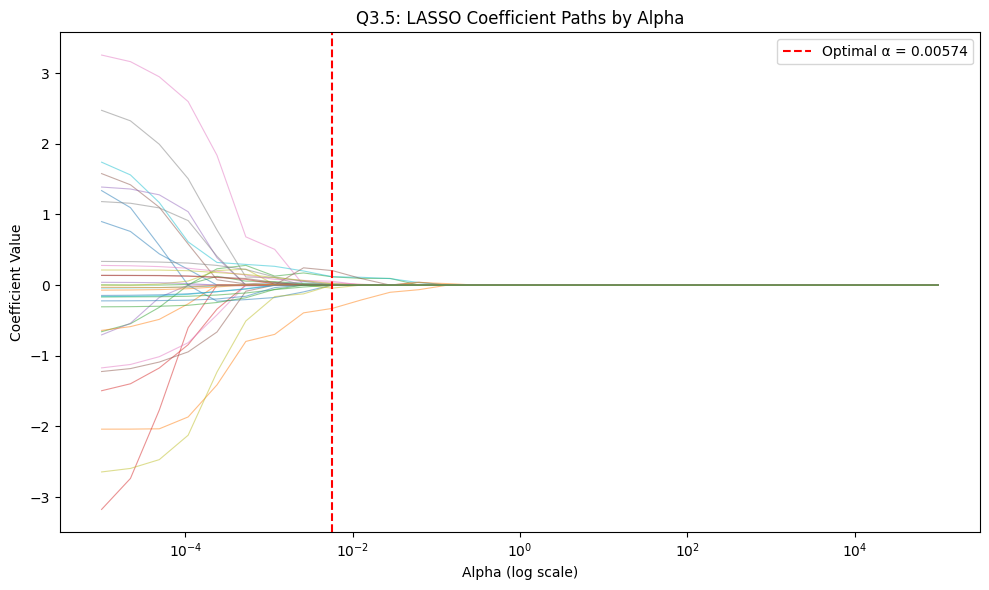

In [34]:
from sklearn.linear_model import Lasso

coef_paths = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X, y)
    coef_paths.append(lasso.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(10, 6))
for j in range(coef_paths.shape[1]):
    plt.plot(alphas, coef_paths[:, j], alpha=0.5, linewidth=0.8)
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Optimal α = {lasso_cv.alpha_:.5f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Q3.5: LASSO Coefficient Paths by Alpha')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
lasso_coefs = lasso_cv.coef_

n_total = len(lasso_coefs)
n_zero = np.sum(lasso_coefs == 0)
n_selected = np.sum(lasso_coefs != 0)

print(f"Total features:    {n_total}")
print(f"Zeroed out:        {n_zero}  ({n_zero/n_total*100:.1f}%)")
print(f"Selected (nonzero):{n_selected}  ({n_selected/n_total*100:.1f}%)\n")

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'OLS Coefficient': lr.coef_,
    'LASSO Coefficient': lasso_coefs
})

print("=== Selected Features (LASSO nonzero) ===")
selected = comparison_df[comparison_df['LASSO Coefficient'] != 0]
print(selected.to_string(index=False))

print("\n=== Coefficients that increased in magnitude (LASSO > OLS) ===")
increased = comparison_df[np.abs(comparison_df['LASSO Coefficient']) > np.abs(comparison_df['OLS Coefficient'])]
print(increased.to_string(index=False))

print("\n=== Coefficients that changed sign ===")
changed_sign = comparison_df[
    (np.sign(comparison_df['OLS Coefficient']) != np.sign(comparison_df['LASSO Coefficient'])) &
    (comparison_df['LASSO Coefficient'] != 0)
]
print(changed_sign.to_string(index=False))

Total features:    33
Zeroed out:        21  (63.6%)
Selected (nonzero):12  (36.4%)

=== Selected Features (LASSO nonzero) ===
                             Feature  OLS Coefficient  LASSO Coefficient
                   ejection_fraction        -2.025371          -0.329656
                    serum_creatinine        -0.739027           0.116875
                               age^3         1.889040           0.117992
                 ejection_fraction^3        -1.253594           0.204822
ejection_fraction^2 serum_creatinine        -1.219271           0.032801
                  serum_creatinine^3        -0.014908          -0.043266
                             anaemia        -0.043420           0.014178
                            diabetes        -0.149472           0.000607
                 high_blood_pressure        -0.073480           0.013608
        diabetes high_blood_pressure         0.282831           0.053968
                    diabetes smoking         0.337922           0.0034

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

**Adding the Ridge penalty $+\alpha (b_1)^2$, the full objective function becomes:**

$$
\mathcal{L}(b_0, b_1) = \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

**Derivative with respect to $b_0$:**

$$
\frac{\partial \mathcal{L}}{\partial b_0} = -\frac{2}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) = 0
$$

This gives:

$$
\sum_{i=1}^n \tilde{y}_i - nb_0 - b_1 \sum_{i=1}^n \tilde{x}_i = 0
$$

This simplifies to:

$$
\boxed{b_0 = 0}
$$

**Derivative with respect to $b_1$:**

Solving for $b_1$:

$$
b_1 \left(\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha \right) = \frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i
$$

$$
\boxed{b_1 = \frac{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha}}
$$

The OLS solution with no penalty would be $b_1^{\text{OLS}} = \frac{\frac{1}{n}\sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum \tilde{x}_i^2}$.


3. How does increasing $\alpha$ change the slope coefficient?

From the Ridge solution:

$$
b_1 = \frac{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha}
$$


**As alpha heads towards infinity, the denominator grows without bound, so b1 goes toward zero. As alpha goes to 0, the solution seems to recovers OLS. So increasing the alpha shrinks the b1 toward zero, but never actually reaches zero for a finite alpha.**


4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?


With the LASSO penalty, the objective becomes:

$$
\mathcal{L}(b_0, b_1) = \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha |b_1|
$$

The challenge is that $|b_1|$ is not differentiable at $b_1 = 0$. We can't take the derivative and set it to zero  because the derivative does not exist at the exact point where the penalty has a kink.

For the second part, there are 2 important parts, the MSE term pulls $b_1$ toward the OLS estimate to fit the data, while the penalty term pulls $b_1$ toward zero. I think it is optimal to set $b_1 = 0$ when the signal in the data is weak compared to the penalty. So basically, when $x$ and $y$ are not strongly correlated, or when $\alpha$ is large enough that the cost of having a nonzero coefficient outweighs the benefit of fitting the data slightly better. I believe that this is the most important reason why LASSO produces exact zeros and performs variable selection, while Ridge on the other hand shrinks coefficients toward zero but never really truly eliminates them.





